In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

In [12]:
from src.preprocessing import (
    load_data,
    split_features_target,
    split_dataset,
    scale_features,
    apply_smote
)

from src.modeling import (
    create_logistic_regression,
    create_random_forest,
    create_xgboost
)

from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    create_metrics_table,
    plot_model_comparison
)

In [26]:
SEED = 42

DATA_PATH = RAW_DIR / "creditcard.csv"

In [14]:
df = load_data(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [17]:
missing_values[missing_values > 0]

Series([], dtype: int64)

## Dataset Overview

The dataset contains anonymized credit card transactions.

Most input features (`V1`–`V28`) were transformed using Principal Component Analysis (PCA), while `Time` and `Amount` remain directly interpretable.

The target variable is `Class`:

- `0` – legitimate transaction
- `1` – fraudulent transaction

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [19]:
class_counts = df["Class"].value_counts()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


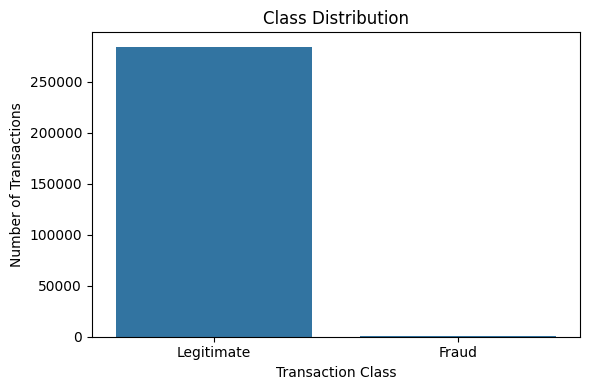

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The dataset is extremely imbalanced.

Fraudulent transactions represent only a very small fraction of all transactions. Because of this imbalance, accuracy alone is not sufficient for evaluating the models.

Metrics such as precision, recall and F1-score are more informative for this classification problem.

In [21]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


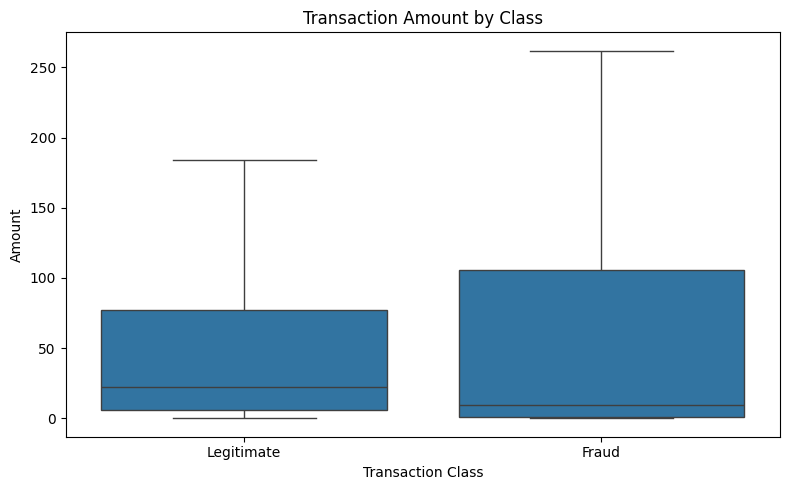

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "amount_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature and Target Separation

The dataset is divided into input features and the target variable `Class`.

In [23]:
X, y = split_features_target(
    df,
    target_column="Class"
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


## Train-Test Split

The dataset is divided into training and test sets using an 80/20 split.

Stratification is used to preserve the original class distribution in both subsets.

In [24]:
X_train, X_test, y_train, y_test = split_dataset(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [25]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## Feature Scaling

The input features are standardized using `StandardScaler`.

The scaler is fitted only on the training data to avoid data leakage.
The same transformation is then applied to the test set.

In [28]:
X_train_scaled, X_test_scaled, scaler = scale_features(
    X_train,
    X_test
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (227845, 30)
Scaled test shape: (56962, 30)


## Handling Class Imbalance with SMOTE

Because fraudulent transactions represent only a very small fraction of the dataset, SMOTE is applied to the training data.

SMOTE generates synthetic samples of the minority class to create a more balanced training set.

The test set remains unchanged so that model evaluation reflects the original class distribution.

In [29]:
X_train_smote, y_train_smote = apply_smote(
    X_train_scaled,
    y_train,
    random_state=SEED
)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## Logistic Regression

Logistic Regression is used as the first classification model.

Because the original training data is highly imbalanced, the model is trained on the SMOTE-resampled training set.

The test set remains unchanged and is used only for final evaluation.

In [30]:
log_model = create_logistic_regression(
    random_state=SEED
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [31]:
y_pred_log = log_model.predict(
    X_test_scaled
)

In [32]:
log_metrics = calculate_metrics(
    y_test,
    y_pred_log
)

log_metrics

{'Accuracy': 0.9741055440469084,
 'Precision': 0.057803468208092484,
 'Recall': 0.9183673469387755,
 'F1-score': 0.10876132930513595}

In [33]:
for metric, value in log_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9741
Precision: 0.0578
Recall: 0.9184
F1-score: 0.1088


### Logistic Regression Results

Logistic Regression achieves high recall, meaning that it successfully detects most fraudulent transactions.

However, its precision is low, which means that many legitimate transactions are incorrectly classified as fraud.

This illustrates an important trade-off in fraud detection: maximizing fraud detection can also increase the number of false alarms.

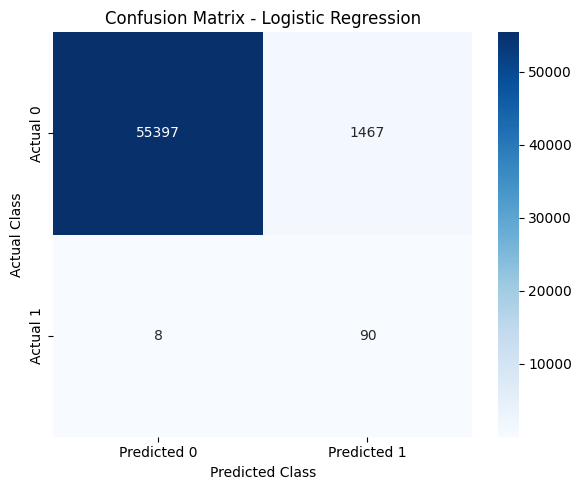

In [34]:
plot_confusion_matrix(
    y_test,
    y_pred_log,
    model_name="Logistic Regression",
    save_path=FIGURES_DIR / "logistic_regression_confusion_matrix.png"
)

In [35]:
model_results = {
    "Logistic Regression": log_metrics
}

## Random Forest

Random Forest is trained on the original training data without SMOTE.

Unlike Logistic Regression, tree-based models do not require feature scaling.

The model is evaluated on the same untouched test set to ensure a fair comparison.

In [36]:
rf_model = create_random_forest(
    random_state=SEED
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [37]:
y_pred_rf = rf_model.predict(
    X_test
)

In [38]:
rf_metrics = calculate_metrics(
    y_test,
    y_pred_rf
)

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9996
Precision: 0.9412
Recall: 0.8163
F1-score: 0.8743


### Random Forest Results

Random Forest achieves very high precision while maintaining strong recall.

Compared with Logistic Regression, it produces significantly fewer false positive predictions and achieves a much higher F1-score.

This indicates a better balance between identifying fraudulent transactions and avoiding unnecessary fraud alerts.

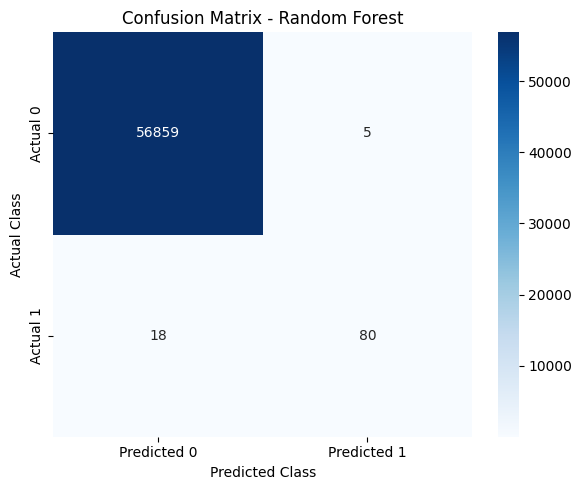

In [39]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    model_name="Random Forest",
    save_path=FIGURES_DIR / "random_forest_confusion_matrix.png"
)

In [40]:
model_results["Random Forest"] = rf_metrics

## XGBoost

XGBoost is trained on the original training data.

Like Random Forest, XGBoost is a tree-based model and does not require feature scaling.

The same untouched test set is used for evaluation.

In [41]:
xgb_model = create_xgboost(
    random_state=SEED
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [42]:
y_pred_xgb = xgb_model.predict(
    X_test
)

In [43]:
xgb_metrics = calculate_metrics(
    y_test,
    y_pred_xgb
)

for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9995
Precision: 0.8941
Recall: 0.7755
F1-score: 0.8306


### XGBoost Results

XGBoost achieves high precision and strong overall performance.

Its recall is lower than that of Random Forest, meaning that it misses a slightly larger number of fraudulent transactions.

However, it still produces relatively few false positive predictions and achieves a high F1-score.

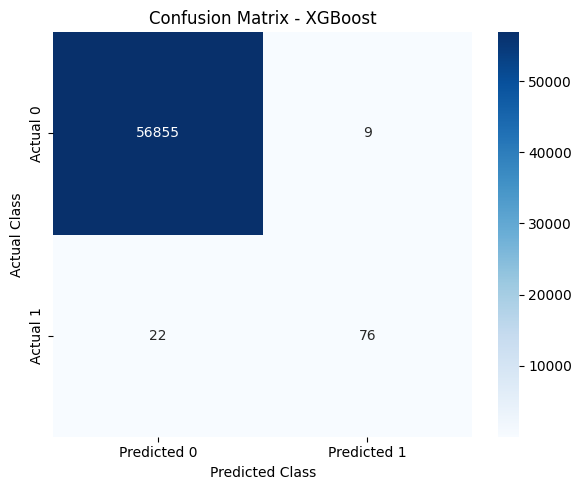

In [44]:
plot_confusion_matrix(
    y_test,
    y_pred_xgb,
    model_name="XGBoost",
    save_path=FIGURES_DIR / "xgboost_confusion_matrix.png"
)

In [45]:
model_results["XGBoost"] = xgb_metrics